# Check single source in DP1 for DCR

Author: Maya Redden, msredden@stanford.edu

In [4]:
# Import packages and define functions

import numpy as np
import matplotlib.pyplot as plt
import galsim

from astropy.io.votable import parse
from scipy.interpolate import interp1d

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation, Angle, AltAz, SkyCoord

import gala.coordinates as gc
import astropy.coordinates as coord

from scipy.optimize import curve_fit

from scipy import integrate


In [2]:
# If data is downloaded from the RSP...

'''
# Load DP1 data
# Need a .vot table of source catalog entries of all visits of a single object
# Need a .vot table of all visits in the survey that overlap with the object


source_file = 'DP1_tests/dp1_test9_source.vot'
source_table = parse(source_file)
source_table = source_table.get_first_table().to_table()

#rename columns to something more descriptive (data must have been downloaded with these columns selected)
source_default_column_names = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17']
source_column_names = ['band','calibFlux','calibFluxErr','coord_dec','coord_ra','dec','decErr','ixx','ixxPSF','ixy','ixyPSF','iyy','iyyPSF','psfFlux','psfFluxErr','ra','raErr','visit']

for i, col in enumerate(source_default_column_names):
    source_table.rename_column(col, source_column_names[i])



visit_file = 'DP1_tests/dp1_ecdfs_allvisits.vot'
visit_table = parse(visit_file)
visit_table = visit_table.get_first_table().to_table()

#rename columns to something more descriptive (data must have been downloaded with these columns selected)
visit_default_column_names = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9', 'col_10']
visit_column_names = ['airmass','altitude','azimuth','band','dec','expTime','ra','skyRotation','visit','zenithDistance','expMidptMJD']

for i, col in enumerate(visit_default_column_names):
    visit_table.rename_column(col, visit_column_names[i])

'''



"\n# Load DP1 data\n# Need a .vot table of source catalog entries of all visits of a single object\n# Need a .vot table of all visits in the survey that overlap with the object\n\n\nsource_file = 'DP1_tests/dp1_test9_source.vot'\nsource_table = parse(source_file)\nsource_table = source_table.get_first_table().to_table()\n\n#rename columns to something more descriptive (data must have been downloaded with these columns selected)\nsource_default_column_names = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17']\nsource_column_names = ['band','calibFlux','calibFluxErr','coord_dec','coord_ra','dec','decErr','ixx','ixxPSF','ixy','ixyPSF','iyy','iyyPSF','psfFlux','psfFluxErr','ra','raErr','visit']\n\nfor i, col in enumerate(source_default_column_names):\n    source_table.rename_column(col, source_column_names[i])\n\n\n\nvisit_file = 'DP1_tests/dp1_ecdfs_allvisits.vot'\nvisit

In [1]:
# Getting data using the tap service on the RSP:

from lsst.rsp import get_tap_service
service = get_tap_service("tap")

def queryTAP(query):
    job = service.submit_job(query)
    job.run()
    job.wait(phases=['COMPLETED', 'ERROR'])
    print('Job phase is', job.phase)
    if job.phase == 'ERROR':
        job.raise_if_error()
    assert job.phase == 'COMPLETED'
    return job.fetch_result().to_table()

# from APIaccess import queryTAP

ra = 53.161541666666665 #deg
dec = -28.160638888888887 #deg

ra, dec = 53.12652887, -28.31641564 #blue GAIA star 
# ra, dec = 52.6969434, -27.9882845 # supernova??? according to SIMBAD
# ra, dec = 53.0455500, -27.9652720 # blue, clearly extended galaxy
# ra, dec = 52.6749434, -27.9750487 # red, extended source
# ra, dec = 53.4881400, -27.7653629
# ra, dec = 53.5058125, -27.8044191 # extended, red galaxy with GAIA counterpart


search_radius = 3 #arcsec

query = f"""SELECT band,
            calibFlux,
            calibFluxErr,
            coord_dec,
            coord_ra,
            dec,
            decErr,
            ixx,
            ixxPSF,
            ixy,
            ixyPSF,
            iyy,
            iyyPSF,
            psfFlux,
            psfFluxErr,
            ra,
            raErr,
            ra_dec_Cov,
            visit 
    FROM dp1.Source 
    WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', {ra}, {dec}, {search_radius/3600}))=1"""

# job = service.submit_job(query)
# job.run()
# job.wait(phases=['COMPLETED', 'ERROR'])
# print('Job phase is', job.phase)
# if job.phase == 'ERROR':
#     job.raise_if_error()
# assert job.phase == 'COMPLETED'
# source_table = job.fetch_result().to_table()

source_table = queryTAP(query)


# ---- visit query ----

visits = source_table['visit']
visit_string = "','".join(map(str, visits))

visit_query = f"""SELECT airmass,altitude,azimuth,band,dec,expTime,ra,skyRotation,visit,zenithDistance,expMidptMJD 
FROM dp1.Visit 
WHERE visit IN ('{visit_string}')"""

# job = service.submit_job(visit_query)
# job.run()
# job.wait(phases=['COMPLETED', 'ERROR'])
# print('Job phase is', job.phase)
# if job.phase == 'ERROR':
#     job.raise_if_error()
# assert job.phase == 'COMPLETED'
# visit_table = job.fetch_result().to_table()

visit_table = queryTAP(visit_query)


Job phase is COMPLETED
Job phase is COMPLETED


In [5]:
#Remove the any source entries found in the same visit, there should be only one source detected for each visit:

visit_IDs = source_table['visit']

has_duplicates = len(visit_IDs) != len(np.unique(visit_IDs))
print("Any duplicates?", has_duplicates)

vals, counts = np.unique(visit_IDs, return_counts=True)
duplicates = vals[counts > 1]
print("Duplicated visits:", duplicates)

source_mask = np.isin(source_table['visit'], duplicates)
source_table = source_table[~source_mask]

Any duplicates? False
Duplicated visits: visit
-----


In [6]:
# Create a master table by joining the source and visit tables

from astropy.table import Table, join

master_all = join(source_table, visit_table, keys = 'visit')
print(master_all.colnames)

['band_1', 'calibFlux', 'calibFluxErr', 'coord_dec', 'coord_ra', 'dec_1', 'decErr', 'ixx', 'ixxPSF', 'ixy', 'ixyPSF', 'iyy', 'iyyPSF', 'psfFlux', 'psfFluxErr', 'ra_1', 'raErr', 'ra_dec_Cov', 'visit', 'airmass', 'altitude', 'azimuth', 'band_2', 'dec_2', 'expTime', 'ra_2', 'skyRotation', 'zenithDistance', 'expMidptMJD']


Mean coordinates:  53.12652887 -28.31641564


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


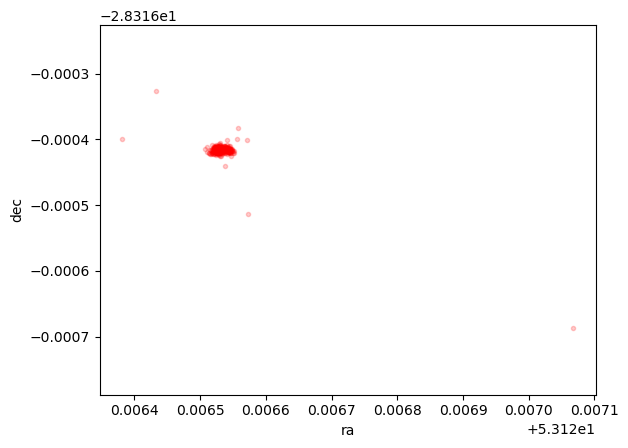

/tmp/ipykernel_1204/3142555160.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


Clipped distribution of points:


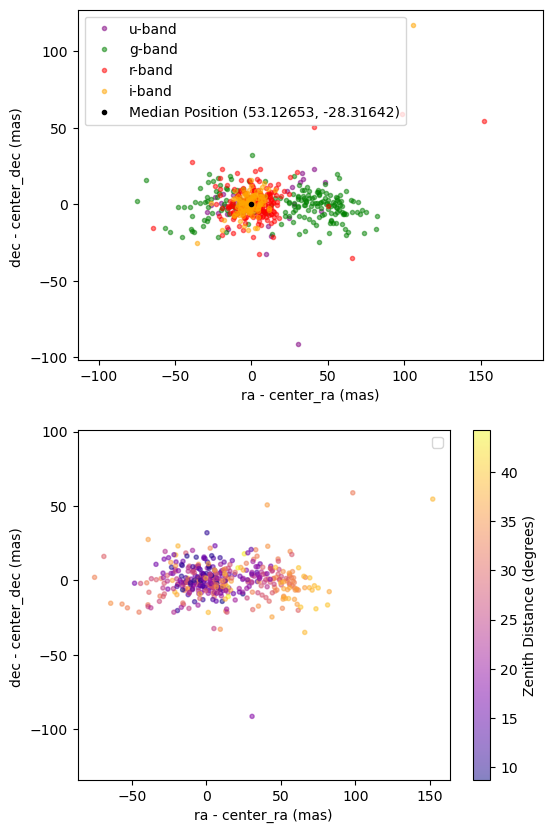

In [7]:
# Plot to check the distribution of visits looks as expected for a single object (limited to a few arcsec)
# If there are outliers, adjust the clipping radius below as needed

center_ra = np.median(master_all['ra_1'])
center_dec = np.median(master_all['dec_1'])

print('Mean coordinates: ', np.round(center_ra, 8), np.round(center_dec, 8))

plt.plot(master_all['ra_1'], master_all['dec_1'], 'r.', alpha = 0.2)
plt.xlabel('ra')
plt.ylabel('dec')
plt.axis('equal')
plt.show()
plt.close()


# create a mask to clip out the outliers:
clipping_radius = 0.0001 # degrees, 0.0001 is ~0.36 arcsec

mask = ((master_all['ra_1'] - center_ra)**2 + (master_all['dec_1'] - center_dec)**2) < (clipping_radius)**2
master = master_all[mask]

master_original = master.copy()

# print('Number of points after clipping: ', len(master))
print('Clipped distribution of points:')


scale = 3600 * 1000 #to convert degrees to milliarcseconds for plotting


# Plot the distribution of points, color coded by band and zenith distance
fig, ax = plt.subplots(2,1, figsize=(6, 10))

colors = {'u': 'purple', 'g': 'green', 'r': 'red', 'i': 'orange'}
for band in 'ugri':
    mask = master['band_1'] == band
    ax[0].plot((master['ra_1'][mask] - center_ra)*scale, (master['dec_1'][mask] - center_dec)*scale, '.', alpha = 0.5, label = f'{band}-band', color=colors[band])

# plt.plot(master['ra_1'], master['dec_1'], 'r.', alpha = 0.2)
# plt.plot(53.12651507954, -28.31641093456, 'b.', label = "GAIA DR3 Position")
# plt.errorbar((53.21692723831 - center_ra)*scale, (-27.92220192498- center_dec)*scale, xerr = 0.1/3600000 * scale, yerr = 0.1/3600000 * scale, fmt = 'k*', label = "GAIA DR3 Position")
ax[0].plot(0, 0, 'k.', label = f"Median Position ({center_ra:.5f}, {center_dec:.5f})")
ax[0].legend()
ax[0].set_xlabel('ra - center_ra (mas)')
ax[0].set_ylabel('dec - center_dec (mas) ')
ax[0].axis('equal')


mask = (master['band_1'] == 'u') | (master['band_1'] == 'g') |(master['band_1'] == 'r')
sc = plt.scatter((master['ra_1']- center_ra)[mask]*scale, (master['dec_1'] - center_dec)[mask]*scale, c=master['zenithDistance'][mask], cmap = 'plasma', alpha = 0.5, marker = '.')
# plt.plot(53.12651507954, -28.31641093456, 'b.', label = "GAIA DR3 Position")
# plt.errorbar((53.21692723831 - center_ra)*scale, (-27.92220192498- center_dec)*scale, xerr = 0.1/3600000 * scale, yerr = 0.1/3600000 * scale, fmt = 'k*', label = "GAIA DR3 Position")
plt.colorbar(sc, label = 'Zenith Distance (degrees)')
# plt.plot(0, 0, 'k.', label = "Median Position")
ax[1].legend()
ax[1].set_xlabel('ra - center_ra (mas)')
ax[1].set_ylabel('dec - center_dec (mas) ')
ax[1].axis('equal')
plt.show()

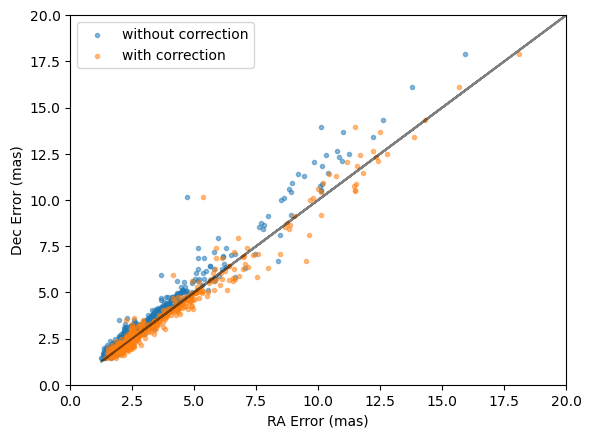

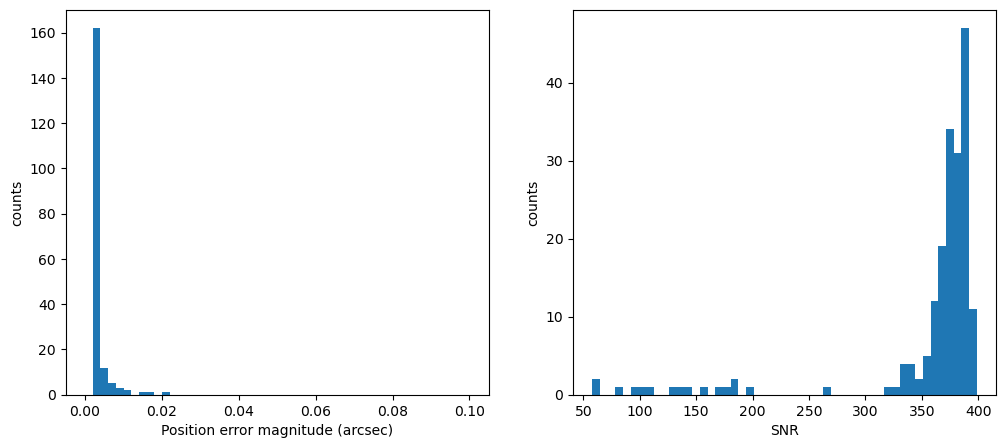

In [33]:
#Apply correction to raErr and ra_dec_Cov to account for overcorrection in DP1
# check distributions of raErr and decErr: (see community forum post for more discussion on this https://community.lsst.org/t/anomalies-in-dp1-right-ascension-errors/11178/13)

correction = np.cos(master_original['dec_1']*np.pi/180)
plt.scatter(master_original['raErr'] * 3600 * 10**3, master_original['decErr'] * 3600 * 10**3, alpha = 0.5,marker = '.', label = 'without correction')
plt.scatter(master_original['raErr']/correction * 3600 * 10**3, master_original['decErr'] * 3600 * 10**3, alpha = 0.5,marker = '.',
 label = 'with correction')
plt.plot(master_original['raErr'] * 3600 * 10**3, master_original['raErr'] * 3600 * 10**3, 'k-', alpha = 0.5)
plt.xlabel('RA Error (mas)')
plt.ylabel('Dec Error (mas)')
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.legend()
plt.show()
plt.close()


#apply correction using master_original to prevent overwriting the already corrected values in master:
master['raErr'] = master_original['raErr']/ correction 
master['ra_dec_Cov'] = master_original['ra_dec_Cov']/correction


fig, ax = plt.subplots(1,2, figsize = (12, 5))

band_mask = master['band_1'] == 'g'

ax[0].hist(np.sqrt(master['raErr'][band_mask]**2 + master['decErr'][band_mask]**2)*3600, 50, range = (0, 0.1)) # magnitude of position error
ax[0].set_xlabel('Position error magnitude (arcsec)')
ax[0].set_ylabel('counts')

ax[1].hist(master['psfFlux'][band_mask]/master['psfFluxErr'][band_mask], 50) # magnitude of position error
ax[1].set_xlabel('SNR')
ax[1].set_ylabel('counts')

plt.show()


In [ ]:
# Add a few columns to the master table: zenith RA/Dec, parallactic angle, and the magnitude of the astrometric shift (from a reference position) projected along the zenith direction

from utils import add_zenith_coordinates, parallactic_angle_from_radec


# Coordinates of the observatory:
lat = -30.244633 #-30:14:40.68
lon = -70.749417 #-70:44:57.90
height = 2647 

# Add zenith coordinates to the master table
master = add_zenith_coordinates(master, lat=lat, lon=lon, height=height)

from utils import parallactic_angle_from_radec_fast
master = parallactic_angle_from_radec_fast(master, lat=lat, lon=lon, height=height)


# Add a column for the parallactic angle and the magnitude of the astrometric shift (from a reference position) projected along the zenith direction
# master['q_'] = np.zeros(len(master))

#calculate the delta R (difference in position along the zenith direction) using two different methods as a sanity check
# method 1 (r_temp) uses the great circle frame transformation in astropy 
# method 2 (r_temp2) uses a simple rotation matrix to rotate the RA/Dec offsets into the parallactic angle frame   
master['r_temp'] = np.zeros(len(master)) 
master['r_temp2'] = np.zeros(len(master))
master['r_err'] = np.zeros(len(master))


# The following should be parallelized for future work
for i in range(len(master)):
    # ra, dec, mjd = master['ra_1', 'dec_1', 'expMidptMJD'][i]
    # par = parallactic_angle_from_radec(ra * u.deg, dec * u.deg, mjd, lat * u.deg, lon * u.deg, height * u.m)
    # # print(par.value)
    # master['q_'][i] = par.value

    pole = coord.SkyCoord(ra=master['zenith_ra'][i]*u.deg, dec=master['zenith_dec'][i]*u.deg, frame='icrs')
    frame = gc.GreatCircleICRSFrame.from_pole_ra0(pole=pole, ra0=100*u.deg)
    c = coord.SkyCoord(ra=[master['ra_1'][i], center_ra]*u.deg, dec=[master['dec_1'][i], center_dec]*u.deg, frame='icrs')
    c_fr = c.transform_to(frame)
    master['r_temp'][i]= (c_fr[0].phi2 -  c_fr[1].phi2).to(u.deg).value

    par = master['q'][i]

    cq, sq = np.cos(par), np.sin(par)
    R = np.array([[cq, -sq], [sq, cq]])
    dRA = (master['ra_1'][i] - center_ra)*np.cos(master['dec_1'][i]*np.pi/180) 
    dDec = master['dec_1'][i] - center_dec
    daz, dalt = R @ np.array([[dRA, dDec]]).T
    master['r_temp2'][i] = dalt
    # master['az_temp'][i] = daz

    # calculate the astrometric uncertainty projected along the zenith direction
    cov_matrix = np.array([[master['raErr'][i]**2, master['ra_dec_Cov'][i]],
                           [master['ra_dec_Cov'][i], master['decErr'][i]**2]])
    r_err_matrix = R @ cov_matrix @ R.T
    master['r_err'][i] = np.sqrt(r_err_matrix[1,1])
    # master['az_err'][i] = np.sqrt(r_err_matrix[0,0])




/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_11686/3177409707.py:53: UserWarning: Warning: converting a masked element to nan.
  cov_matrix = np.array([[master['raErr'][i]**2, master['ra_dec_Cov'][i]],


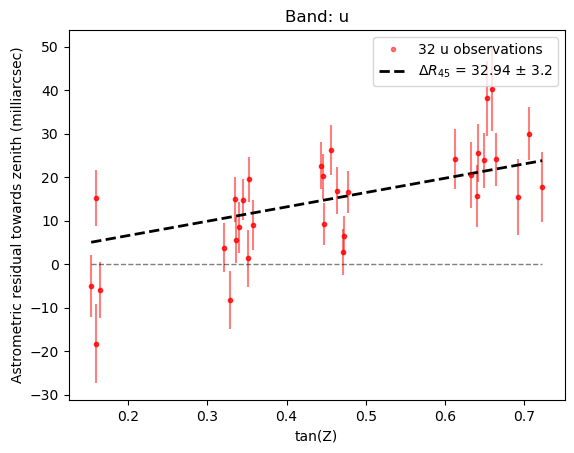

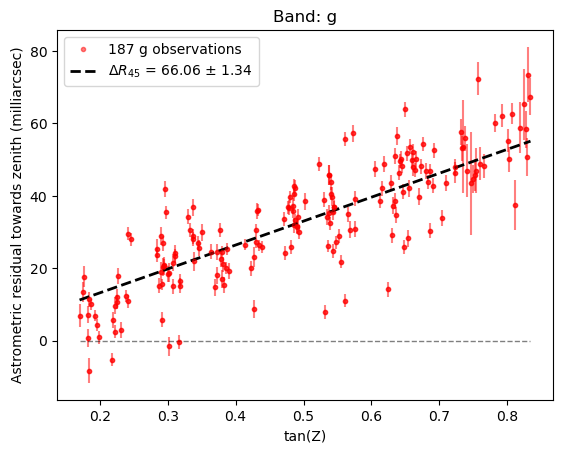

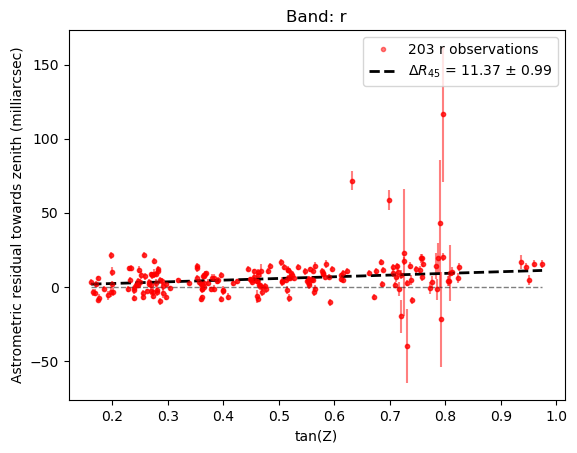

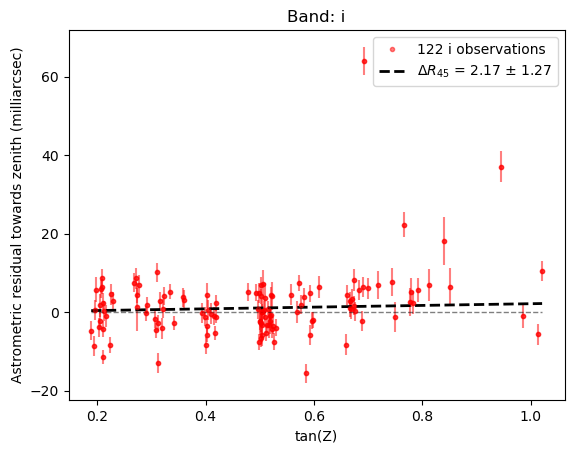

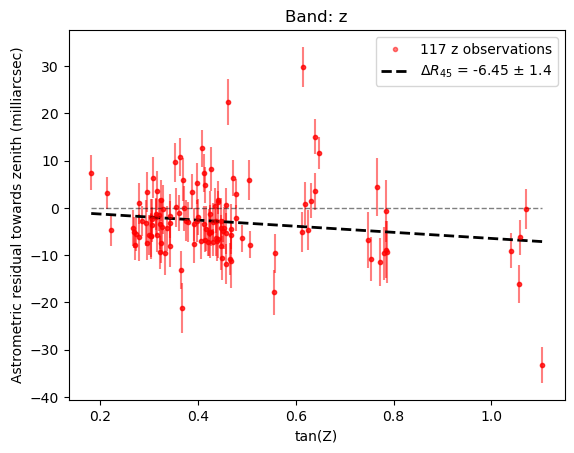

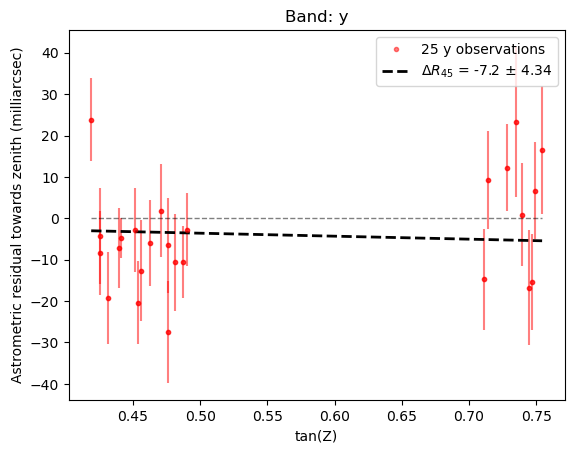

In [32]:
# Plot the residuals along the zenith direction vs zenith angle, for each band
# Also plot a trendline of the form A*tan(z)

def dR_model(z, c):
    return c * np.tan(z * np.pi/180)

for band in 'ugrizy':
    band_mask = master['band_1'] == band

    #Optional: add another mask to throw out large errors
    error_mask = master['r_err'] <  50 / ( 3600 * 10**3)# degrees
    band_mask = band_mask & error_mask

    if np.sum(band_mask) > 0:

        airmass = master[band_mask]['airmass']
        z = np.arccos(1 / airmass) * 180 / np.pi
        tanZ = np.tan(z * np.pi/180)
        
        dR = master['r_temp'][band_mask]
        dR_err = master['r_err'][band_mask]

        popt, pcov = curve_fit(dR_model, z, dR, sigma = dR_err, p0 = [0])
        perr = np.sqrt(np.diag(pcov))
        
        #plot dR in milliarcsec as a function of tan(zenith angle)
        plt.plot(tanZ, dR * 3600 * 10**3,  ls = '', marker = '.', alpha = 0.5, color = 'r', label = f'{len(dR)} {band} observations')
        plt.errorbar(tanZ, dR * 3600 * 10**3, yerr = dR_err * 3600 * 10**3, ls = '', marker = '.', alpha = 0.5, color = 'r')
        
        #plot a trendline
        z_temp = np.linspace(min(z), max(z), 20) 
        tanZ_temp = np.tan(z_temp * np.pi/180)
        plt.plot(tanZ_temp, dR_model(z_temp, *popt) * 3600 * 10**3, 'k--', linewidth = 2, label = rf'$\Delta R_{{45}}$ = {np.round(popt[0]*3600*1000, 2)} $\pm$ {np.round(perr[0]*3600*1000, 2)}') #label = 'Trendline: A tan(z)')

        plt.plot(tanZ_temp, np.zeros(len(z_temp)) * 3600 * 10**3, 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')
        
        plt.title(f'Band: {band}')
        plt.xlabel('tan(Z)')
        plt.ylabel('Astrometric residual towards zenith (milliarcsec)')
        plt.legend()
        plt.show()
        plt.close()



<>:109: SyntaxWarning: invalid escape sequence '\D'
<>:109: SyntaxWarning: invalid escape sequence '\D'
/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_11686/1831874846.py:109: SyntaxWarning: invalid escape sequence '\D'
  print('expected \Delta R_45: ', model_dR[band][-1]*1e3)


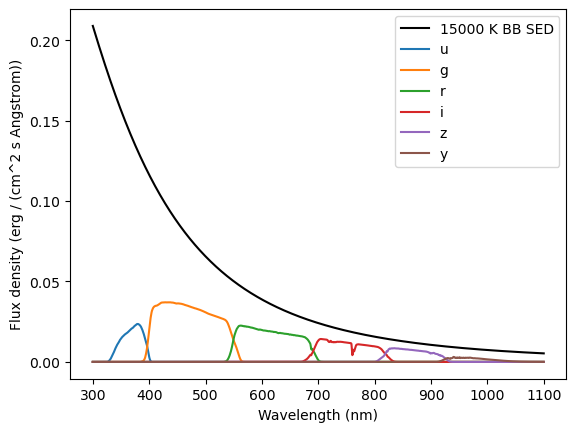

g-r color of source:  -0.6609
0.032936951927347975 0.003202854042397053
Estimated wavelength for band u: 369.93 nm (+ 0.34 / - 0.34)
expected \Delta R_45:  32.66713765965079
Simulated BB estimated wavelength for band {band}:  369.96  nm


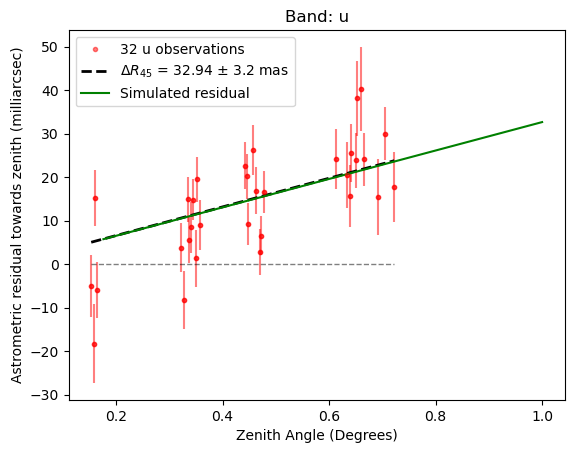

0.0660636580208893 0.0013374608707362836
Estimated wavelength for band g: 470.19 nm (+ 0.31 / - 0.31)
expected \Delta R_45:  57.559460842483645
Simulated BB estimated wavelength for band {band}:  472.2  nm


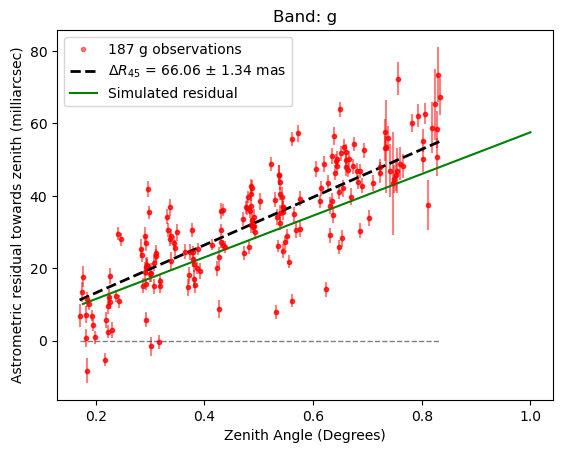

0.011369722859574554 0.00098766895121367
Estimated wavelength for band r: 616.44 nm (+ 0.53 / - 0.53)
expected \Delta R_45:  13.999235476724436
Simulated BB estimated wavelength for band {band}:  615.03  nm


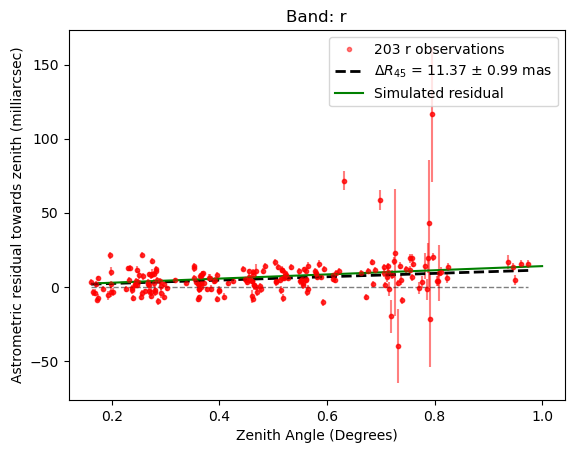

0.0021748534374621104 0.0012742907531992525
Estimated wavelength for band i: 752.4 nm (+ 1.25 / - 1.24)
expected \Delta R_45:  4.35209950019555
Simulated BB estimated wavelength for band {band}:  750.29  nm


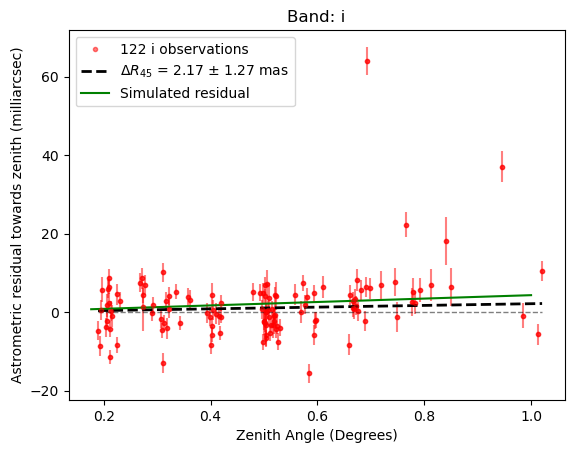

-0.006453347085175267 0.0014011893676284452
Estimated wavelength for band z: 876.58 nm (+ 2.21 / - 2.19)
expected \Delta R_45:  1.3335112933461346
Simulated BB estimated wavelength for band {band}:  864.72  nm


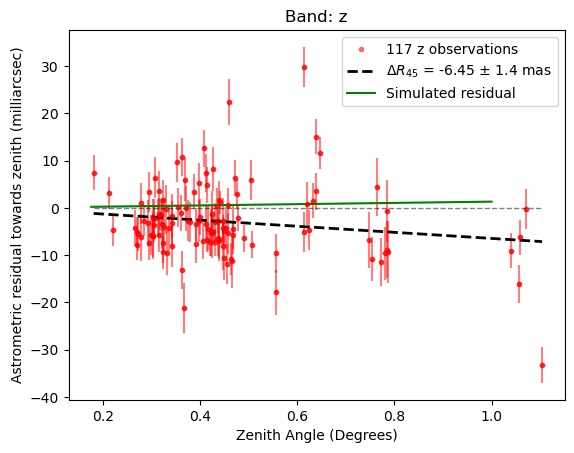

-0.007200355944332405 0.004343362010618302
Estimated wavelength for band y: 989.23 nm (+ 9.82 / - 9.44)
expected \Delta R_45:  0.8547265325091757
Simulated BB estimated wavelength for band {band}:  972.0  nm


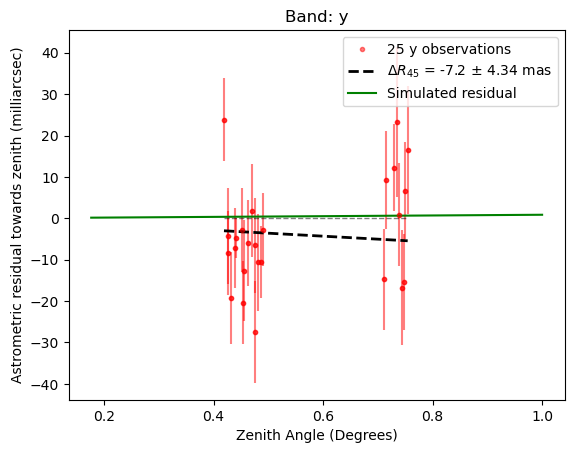

In [ ]:
# Recreate the plots above but add a simulated model of the residuals
# The model uses a blackbody SED of a specified temperature as the source, and a second blackbody SED of a different temperature as the reference


from astropy.modeling.models import BlackBody
from astropy.constants import c
import astropy.units as u
from utils import BB, apply_filter
from utils import apply_DCR, weighted_avg_and_std


# Define the source and reference temperatures:
source_temperature = 15000 #K
reference_temperature = 5000 #K


wavelengths = np.linspace(300, 1100, 1000) # nm #np.logspace(np.log10(3050), np.log10(11400), num=1000) # Angstroms

plt.plot(wavelengths, BB(wavelengths, source_temperature, 1e-9), 'k-', label = f'{source_temperature} K BB SED')

filtered_bb = {}
Flux = {}

for band in 'ugrizy':
    fluxes = [BB(wavelengths, source_temperature, 1e-9), BB(wavelengths, reference_temperature, 1e-9),  np.ones(len(wavelengths))*np.max(BB(wavelengths, source_temperature, 1e-9))*0.1]
    filtered_bb[band]= apply_filter(wavelengths , fluxes, band) # apply filter takes wavelengths in nm
    Flux[band] = integrate.simpson(filtered_bb[band][0], wavelengths)
    plt.plot(wavelengths, filtered_bb[band][0], label = f'{band}') # flux: {np.round(Flux[band], 4)}')

plt.legend()
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux density (erg / (cm^2 s Angstrom))')
plt.show()
plt.close()

gr_color = -2.5 * np.log10(Flux['g'] / Flux['r'])
print('g-r color of source: ', np.round(gr_color, 4))



# Calculate the DCR effect for a range of zenith angles

zeniths = np.linspace(10, 45, 10) #degrees

#Matthew's atmospheric conditions
pressure=70.0,  # kPa
temperature=293.15,  # K
H2O_pressure=0.0,

#Pat and Josh's paper atmospheric conditions 
pressure=69.328
temperature=293.15
H2O_pressure=1.067


model_dR = {}
for band in 'ugrizy':
    model_dR[band] = np.array([])

model_stdevs = {}
for band in 'ugrizy':
    model_stdevs[band] = np.array([])

for zenith in zeniths:

    refraction_angles, filtered_refracted_data = apply_DCR(wavelengths, filtered_bb, zenith, pressure, temperature, H2O_pressure)

    means, stdevs = weighted_avg_and_std(refraction_angles, filtered_refracted_data, multi = True)

    for band in 'ugrizy':
        model_dR[band] = np.append(model_dR[band], means[band][0] - means[band][1]) #difference between source and reference SEDs
        model_stdevs[band] = np.append(model_stdevs[band], stdevs[band][0]) #just the source SED stdev



from wavelength_estimate import generate_templates, estimate_mean_wave
templates = generate_templates(reference_temperature = 4500, sigma = 100, gaussian = False)

# Plot the model results on top of the data

for band in 'ugrizy':
    band_mask = master['band_1'] == band


    #add another band mask to throw out large errors
    error_mask = master['r_err']<  100 / ( 3600 * 10**3)# degrees
    band_mask = band_mask & error_mask


    if np.sum(band_mask) > 0:

        
        airmass = master[band_mask]['airmass']
        z = np.arccos(1 / airmass) * 180 / np.pi
        tanz = np.tan(z * np.pi/180)

        dR = master['r_temp'][band_mask]
        dR_err = master['r_err'][band_mask]

        popt, pcov = curve_fit(dR_model, z, dR, sigma = dR_err, p0 = [0])
        perr = np.sqrt(np.diag(pcov))
        print(popt[0]*3600, perr[0]*3600)

        wave_max, wave_mean, wave_min = estimate_mean_wave(np.array([popt[0] - perr[0], popt[0], popt[0] + perr[0]])*3600, band, *templates)
        print(f'Estimated wavelength for band {band}: {np.round(wave_mean, 2)} nm (+ {np.round(wave_max - wave_mean, 2)} / - {np.round(wave_mean - wave_min, 2)})')
        # print('BB estimated wavelength for band {band}: ', np.round(BB_mean_wavelengths[band][0], 2)/10, ' nm')
        # print('BB reference wavelength for band {band}: ', np.round(BB_mean_wavelengths[band][1], 2)/10, ' nm')
        print('expected \Delta R_45: ', model_dR[band][-1]*1e3)
        wave_sim = estimate_mean_wave(np.array([model_dR[band][-1]]), band, *templates)[0]
        print('Simulated BB estimated wavelength for band {band}: ', np.round(wave_sim, 2), ' nm')


        plt.plot(tanz, dR * 3600 * 10**3,  ls = '', marker = '.', alpha = 0.5, color = 'r', label = f'{len(dR)} {band} observations') #label = f'Source:  {np.round(center_ra, 4)}, {np.round(center_dec, 4)}')
        plt.errorbar(tanz, dR * 3600 * 10**3, yerr = dR_err * 3600 * 10**3, ls = '', marker = '.', alpha = 0.5, color = 'r')
        
        z_temp = np.linspace(min(z), max(z), 20) 
        tanz_temp = np.tan(z_temp * np.pi/180)
        plt.plot(tanz_temp, dR_model(z_temp, *popt) * 3600 * 10**3, 'k--', linewidth = 2, label = rf'$\Delta R_{{45}}$ = {np.round(popt[0]*3600*1000, 2)} $\pm$ {np.round(perr[0]*3600*1000, 2)} mas')#'Trendline: A tan(z)')
        plt.plot(tanz_temp, np.zeros(len(z_temp)) * 3600 * 10**3, 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')
        plt.plot(np.tan(zeniths * np.pi/180), model_dR[band] * 10**3 , 'g-', label = f'Simulated residual') #{source_temperature} K star (reference: {reference_temperature} K star)')
        
        plt.title(f'Band: {band}')
        plt.xlabel('Zenith Angle (Degrees)')
        plt.ylabel('Astrometric residual towards zenith (milliarcsec)')
        plt.legend()

        # plt.savefig(f'scrap/dp1_dcr_model_fit_{band}.pdf')

        plt.show()
        plt.close()

0.04948843942852335 0.009612573334066947
0.014757981715099306 0.0026262752485060764
0.07311785527556236 0.0039738177068106215
0.008490918920059702 0.0034513920037545823


Text(0.78, 0.09999999999999998, 'i band')

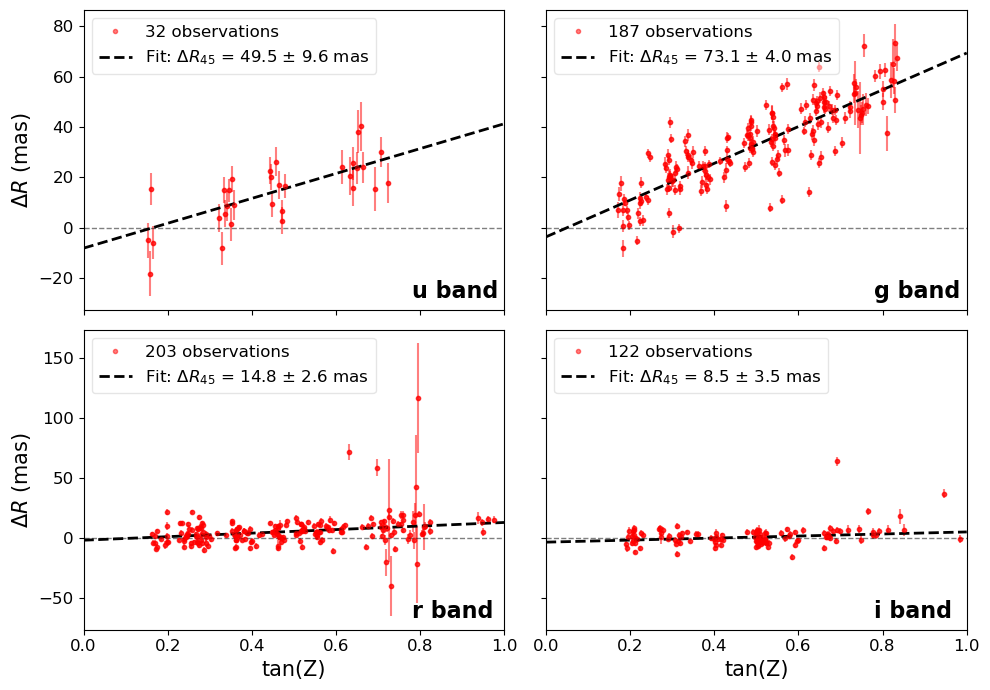

In [ ]:
# Plot in a grid for publishing 


def dR_model2(z, R, c):
    return R * np.tan(z * np.pi/180) + c
fig, ax = plt.subplots(2, 2, figsize=(10,7), sharey = 'row', sharex = True)

for i, band in enumerate('urgi'):
    band_mask = master['band_1'] == band

    #add another band mask to throw out large errors
    error_mask = master['r_err']<  200 / ( 3600 * 10**3)# degrees
    band_mask = band_mask & error_mask
    

    if np.sum(band_mask) > 0:

        
        airmass = master[band_mask]['airmass']
        z = np.arccos(1 / airmass) * 180 / np.pi

        z_ = np.tan(z * np.pi/180) #fit in tan(z) space since that is the expected functional form of the DCR effect
        zeniths_ = np.tan(zeniths * np.pi/180)
        
        dR = master['r_temp'][band_mask]
        dR_err = master['r_err'][band_mask]

        popt, pcov = curve_fit(dR_model2, z, dR, sigma = dR_err, p0 = [0 / (3600 * 10**3), 0])
        perr = np.sqrt(np.diag(pcov))
        print(popt[0]*3600, perr[0]*3600)

        n = i // 2
        m = i % 2



        ax[m, n].plot(z_, dR * 3600 * 10**3,  ls = '', marker = '.', alpha = 0.5, color = 'r', label = f'{len(dR)} observations') #label = f'Source:  {np.round(center_ra, 4)}, {np.round(center_dec, 4)}')
        ax[m, n].errorbar(z_, dR * 3600 * 10**3, yerr = dR_err * 3600 * 10**3, ls = '', marker = '.', alpha = 0.5, color = 'r')
        z_temp = np.linspace(0, 45, 20) 
        z_temp_ = np.tan(z_temp * np.pi/180)

        ax[m, n].plot(z_temp_, dR_model2(z_temp, *popt) * 3600 * 10**3, 'k--', linewidth = 2, label = rf'Fit: $\Delta R_{{45}}$ = {np.round(popt[0]*3600*1000, 1)} $\pm$ {np.round(perr[0]*3600*1000, 1)} mas')#'Trendline: A tan(z)')
        ax[m, n].plot(z_temp_, np.zeros(len(z_temp_)) * 3600 * 10**3, 'k--', alpha = 0.5, linewidth = 1) #, label = 'Flat')
        # ax[m, n].plot(zeniths_, model_dR[band] * 10**3 , 'g-', label = f'Expected: $\Delta R_{{45}}$ = {np.round(model_dR[band][-1]*1e3, 1)} mas') #{source_temperature} K star (reference: {reference_temperature} K star)')
        # ax[m, n].set_title(f'Band: {band}', fontsize = 16)
        # ax[m, n].set_xlabel('Zenith Angle (Degrees)', fontsize = 12)
        # ax[m, n].set_ylabel(r'$\Delta R$ (mas)', fontsize = 12)
        ax[m, n].set_xlim(0, 1)
        ax[m, n].legend(loc = 'upper left',fontsize = 12, framealpha = 0.5)
        ax[m, n].tick_params(axis='both', which='major', labelsize=12)
        # ax[m, n].set_xticks([0, 5, 10,15, 20, 25, 30, 35, 40, 45])

        # plt.savefig(f'scrap/dp1_dcr_model_fit_{band}.pdf')

        # plt.show()
        # plt.close()

fig.subplots_adjust(wspace=0) 
ax[0,0].set_ylabel(r'$\Delta R$ (mas)', fontsize = 15)
ax[1,0].set_ylabel(r'$\Delta R$ (mas)', fontsize = 15)
ax[1,0].set_xlabel('tan(Z)', fontsize = 15)
ax[1,1].set_xlabel('tan(Z)', fontsize = 15)
plt.tight_layout()

ax[0,0].text(0.78, 1 - 0.9, 'u band', transform=ax[0,0].transAxes, fontsize=16, fontweight='bold', va='top')
ax[0,1].text(0.78, 1 - 0.9, 'g band', transform=ax[0,1].transAxes, fontsize=16, fontweight='bold', va='top')
ax[1,0].text(0.78, 1 - 0.9, 'r band', transform=ax[1,0].transAxes, fontsize=16, fontweight='bold', va='top')
ax[1,1].text(0.78, 1 - 0.9, 'i band', transform=ax[1,1].transAxes, fontsize=16, fontweight='bold', va='top')

# fig.savefig(f'scrap/dp1_dcr_model_fit_grid2.pdf')